In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdb
from IPython.display import display
import os

In [3]:
import ee
import geemap
service_account = ' boba-account@boba-430314.iam.gserviceaccount.com '
credentials = ee.ServiceAccountCredentials(service_account,'C:/Users/arj26323/OneDrive - University of Georgia/Documents/GEE AUTH/boba-430314-a19be859bfca.json')

ee.Initialize(credentials)

print(geemap.__version__)

0.34.1


In [4]:
# 1. Define your 4 target pixels (lat, lon) IN ORDER N TO S!
sites = {
    "A": (31.86948, -81.00784), ##Steep decline
    "B": (31.44690, -81.22984), ##moderate increase
    "C": (31.30184, -81.28859), ##steep increase
    "D": (30.828699, -81.614158) ##intermediate decline
}

In [5]:
# Convert to FeatureCollection
features = []

for name, (lat, lon) in sites.items():
    
    point = ee.Geometry.Point([lon, lat])

    feature = ee.Feature(point, {
        'site': name
    })

    features.append(feature)

sites_fc = ee.FeatureCollection(features)

test_pixel = sites_fc

In [6]:
Map = geemap.Map(center=sites['A'], zoom=10)
Map.addLayer(test_pixel, {}, 'Sampling area')
Map

Map(center=[31.86948, -81.00784], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Searc…

In [7]:
def maskL8sr(image):
    qaMask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturationMask = image.select('QA_RADSAT').eq(0)
    # Apply the scaling factors to the appropriate bands.
    opticalBands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermalBands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    # Replace the original bands with the scaled ones and apply the masks.
    return image.addBands(opticalBands, None, True) \
    .addBands(thermalBands, None, True) \
    .updateMask(qaMask) \
    .updateMask(saturationMask)

##Add Flats

def addFLATSL7(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(RED-SWIR)/(RED+SWIR) - 41.2*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1)))', {
            'SWIR': image.select('SR_B5'),
            'NIR': image.select('SR_B4'),
            'RED': image.select('SR_B3'),
            'BLUE': image.select('SR_B1')
        })
    
    return image.addBands(flats.rename('flats'))

def addFLATSL5(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(0.972*(RED-SWIR)/(RED+SWIR)-0.008) - 41.2*(0.991*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1)-0.0014)))', {
            'SWIR': image.select('SR_B5'),
            'NIR': image.select('SR_B4'),
            'RED': image.select('SR_B3'),
            'BLUE': image.select('SR_B1')
        })
    
    return image.addBands(flats.rename('flats'))


def addFLATSL8(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(0.841*(RED-SWIR)/(RED+SWIR) - 0.019) - 41.2*(0.771*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1) + 0.011)))', {
            'SWIR': image.select('SR_B6'),
            'NIR': image.select('SR_B5'),
            'RED': image.select('SR_B4'),
            'BLUE': image.select('SR_B2')
        })
    
    return image.addBands(flats.rename('flats'))

def addFLATSL9(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(1.225*(RED-SWIR)/(RED+SWIR) + 0.096) - 41.2*(1.038* (NIR-RED)/(NIR+6*RED-7.5*BLUE+1) - 0.004)))', {
            'SWIR': image.select('SR_B6'),
            'NIR': image.select('SR_B5'),
            'RED': image.select('SR_B4'),
            'BLUE': image.select('SR_B2')
        })
    
    return image.addBands(flats.rename('flats'))

##MASKING FLATS
def maskFLATS(image):
    mask1 = image.select('flats').lte(0.2)
    return image.updateMask(mask1)

In [8]:
#Datasets - MASKING FLATS (try not masking later)
ls5_collect = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterBounds(test_pixel).map(maskL8sr).map(addFLATSL5).map(maskFLATS)
ls7_collect = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterBounds(test_pixel).map(maskL8sr).map(addFLATSL7).map(maskFLATS)
ls8_collect = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterBounds(test_pixel).map(maskL8sr).map(addFLATSL8).map(maskFLATS)
ls9_collect = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterBounds(test_pixel).map(maskL8sr).map(addFLATSL8).map(maskFLATS)

#Merge
ultra_col = ls8_collect.merge(ls5_collect).merge(ls7_collect).merge(ls9_collect)

#Gridmet
gridmet = ee.ImageCollection('GRIDMET/DROUGHT').filterBounds(test_pixel)

#Daymet
daymet = ee.ImageCollection('NASA/ORNL/DAYMET_V4').filterBounds(test_pixel)

In [9]:
# # Print the number of available images per year BEFORE calculating max EVI
# for y in [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]:
#     start = f"{y}-08-01"
#     end = f"{y}-10-31"
#     count = ultra_col.filterDate(start, end).size().getInfo()
#     print(f"Year {y}: {count} valid images available after masking")

In [10]:
def harmonize_landsat(img):
    sat = ee.String(img.get('SPACECRAFT_ID'))

    # Your original working index logic
    is_l5 = sat.index('LANDSAT_5').gte(0)
    is_l7 = sat.index('LANDSAT_7').gte(0)
    
    # Combine them into a single boolean: Is it L5 OR L7?
    is_l57 = is_l5.Or(is_l7)

    img_l57 = img.select(['SR_B7', 'SR_B4', 'SR_B3', 'SR_B2','SR_B1']).rename(['SWIR2', 'NIR', 'Red', 'Green', 'Blue'])
    img_l89 = img.select(['SR_B7', 'SR_B5', 'SR_B4', 'SR_B3','SR_B2']).rename(['SWIR2', 'NIR', 'Red', 'Green', 'Blue'])
    
    # Use the server-side If condition
    harmonized = ee.Image(ee.Algorithms.If(is_l57, img_l57, img_l89))
    
    # CRITICAL: Return the final image out of the function!
    return harmonized.copyProperties(img, img.propertyNames())

##Just looking at periods of change here
years_list = ee.List.sequence(1984,2023)

##evi
def add_evi(image):

    evi = (
        image.select('NIR')
        .subtract(image.select('Red'))
        .multiply(2.5)
        .divide(
            image.select('NIR')
            .add(image.select('Red').multiply(6))
            .add(image.select('Blue').multiply(7.5))
            .add(1)
        )
    )

    return image.addBands(evi.rename('evi'))


def get_evi_max_05_10(year):
    year = ee.Number(year)
    
    # Construct dates entirely on the server side
    start_date = ee.Date.fromYMD(year, 5, 1)
    end_date = ee.Date.fromYMD(year, 10, 31)
    
    # Filter, harmonize, and calculate max EVI for this specific year
    evi_images = (ultra_col
                  .filterDate(start_date, end_date)
                  .map(harmonize_landsat)
                  .map(add_evi)) # Assuming add_evi is defined elsewhere
    
    # Return the max image, casting to ee.Image, and set the year as a property
    return (evi_images.select('evi')
            .max()
            .rename('evi_max_05_10')
            .set('year', year))

# This results in an ImageCollection of yearly max EVI images
evi_coll = ee.ImageCollection(years_list.map(get_evi_max_05_10))

def add_nd_swir2_nir(image):

    nd = (
        image.select('SWIR2')
        .subtract(image.select('NIR'))
        .divide(
            image.select('SWIR2')
            .add(image.select('NIR'))
        )
    )

    return image.addBands(nd.rename('nd_swir2_nir'))

def get_nd_swir2_nir_mean_05_10(year):
    year = ee.Number(year)
    
    # Construct dates entirely on the server side
    start_date = ee.Date.fromYMD(year, 5, 1)
    end_date = ee.Date.fromYMD(year, 10, 31)
    
    # Filter, harmonize, and calculate max EVI for this specific year
    swir2nir_images = (ultra_col
                  .filterDate(start_date, end_date)
                  .map(harmonize_landsat)
                  .map(add_nd_swir2_nir))
    
    # Return the max image, casting to ee.Image, and set the year as a property
    return (swir2nir_images.select('nd_swir2_nir')
            .mean()
            .rename('nd_swir2_nir_mean_05_10')
            .set('year', year))

# This results in an ImageCollection 
swir2nir_coll = ee.ImageCollection(years_list.map(get_nd_swir2_nir_mean_05_10))   

##spei14d
def get_spei14d(year):
    year = ee.Number(year)
    return (
        gridmet
        .filterBounds(test_pixel)
        .filterDate(
            ee.Date.fromYMD(year, 8, 1),
            ee.Date.fromYMD(year, 10, 31)
        )
        .select('spei14d')
        .mean()
        .rename('spei14d')
        .set('year', year)
    )


##dayl Max
def get_daylMax(year):
    year = ee.Number(year)
    return (
        daymet
        .filterBounds(test_pixel)
        .filterDate(
            ee.Date.fromYMD(year, 5, 1),
            ee.Date.fromYMD(year, 10, 31)
        )
        .select('dayl')
        .max()
        .rename('dayl_Max')
        .set('year', year)
    )


def add_ndvi(image):

    ndvi = (
        image.select('NIR')
        .subtract(image.select('Red'))
        .divide(
            image.select('NIR')
            .add(image.select('Red'))
        )
    )

    return image.addBands(ndvi.rename('ndvi'))

def get_ndvi_mean_08_10(year):
    year = ee.Number(year)
    
    # Construct dates entirely on the server side
    start_date = ee.Date.fromYMD(year, 8, 1)
    end_date = ee.Date.fromYMD(year, 10, 31)
    
    # Filter, harmonize, and calculate max EVI for this specific year
    ndvi_images = (ultra_col
                  .filterDate(start_date, end_date)
                  .map(harmonize_landsat)
                  .map(add_ndvi))
    
    # Return the max image, casting to ee.Image, and set the year as a property
    return (ndvi_images.select('ndvi')
            .mean()
            .rename('ndvi_mean_08_10')
            .set('year', year))

# This results in an ImageCollection 
ndvi_coll = ee.ImageCollection(years_list.map(get_ndvi_mean_08_10)) 


##srad_peak
def getSRADpeak(year):
    year = ee.Number(year)
    return (
        daymet
        .filterBounds(test_pixel)
        .filterDate(
            ee.Date.fromYMD(year, 8, 1),
            ee.Date.fromYMD(year, 10, 31)
        )
        .select('srad')
        .mean()
        .rename('srad_peak')
        .set('year', year)
    )


def add_nd_r_g(image):

    nd = (
        image.select('Red')
        .subtract(image.select('Green'))
        .divide(
            image.select('Red')
            .add(image.select('Green'))
        )
    )

    return image.addBands(nd.rename('nd_r_g'))

def get_nd_r_g_max_05_10(year):
    year = ee.Number(year)
    
    # Construct dates entirely on the server side
    start_date = ee.Date.fromYMD(year, 5, 1)
    end_date = ee.Date.fromYMD(year, 10, 31)
    
    # Filter, harmonize, and calculate max EVI for this specific year
    nd_r_g_images = (ultra_col
                  .filterDate(start_date, end_date)
                  .map(harmonize_landsat)
                  .map(add_nd_r_g))
    
    # Return the max image, casting to ee.Image, and set the year as a property
    return (nd_r_g_images.select('nd_r_g')
            .max()
            .rename('nd_r_g_max_05_10')
            .set('year', year))

# This results in an ImageCollection 
nd_r_g_coll = ee.ImageCollection(years_list.map(get_nd_r_g_max_05_10)) 


In [11]:
##Next steps - clean up 'gce' and location of extraction, introduce daymet and gridmet datasets, begin extraction.

In [12]:
#Raster extraction
def rasterExtraction(image):
    # The function pulls 'test_pixel' from your main script environment
    return image.sampleRegions(
        collection=test_pixel,  # Updated to use your variable directly
        scale=30,
        tileScale=8  
    ).map(lambda f: f.set('year', image.get('year'))) 


In [13]:
##Filtering the image collections
srad_coll = ee.ImageCollection(years_list.map(getSRADpeak))
daylMax_coll = ee.ImageCollection(years_list.map(get_daylMax))
spei14d_coll = ee.ImageCollection(years_list.map(get_spei14d))


In [14]:
# swir2nir_coll.getInfo()
# evi_coll
# ndvi_coll
# nd_r_g_coll
# srad_coll
# daylMax_coll
# spei14d_coll.getInfo()

In [15]:
# 1. Put ALL your summarized collections into a list
# (Make sure every image in these collections has a 'year' property)
all_collections = [
    evi_coll,      # Collection 1
    srad_coll,     # Collection 2
    swir2nir_coll,       # Collection 3
    ndvi_coll,     # Collection 4
    nd_r_g_coll,     # Collection 5
    daylMax_coll,      # Collection 6
    spei14d_coll     # Collection 7
]

# 2. Extract the first collection to act as the "starting point" (the base)
base_collection = all_collections[0]

# 3. Put the remaining collections into an Earth Engine server-side list
remaining_collections = ee.List(all_collections[1:])

# 4. Define the join function that will run iteratively on the server
def join_next_collection(next_coll, current_master):
    next_coll = ee.ImageCollection(next_coll)
    current_master = ee.ImageCollection(current_master)
    
    # Filter to match the 'year' property
    year_filter = ee.Filter.equals(leftField='year', rightField='year')
    inner_join = ee.Join.inner()
    
    # Apply the join
    joined = inner_join.apply(current_master, next_coll, year_filter)
    
    # Map over the join results to merge the bands horizontally
    def combine_bands(feature):
        primary_img = ee.Image(feature.get('primary'))
        secondary_img = ee.Image(feature.get('secondary'))
        return primary_img.addBands(secondary_img)
        
    return ee.ImageCollection(joined.map(combine_bands))

# 5. Use .iterate() to loop through and merge all bands into one master collection
master_collection = ee.ImageCollection(
    remaining_collections.iterate(join_next_collection, base_collection)
)

In [16]:
pixel_df = master_collection.map(rasterExtraction).flatten()

In [17]:
print(spei14d_coll.size().getInfo())


40


In [18]:
print(master_collection.first().getInfo())

{'type': 'Image', 'bands': [{'id': 'evi_max_05_10', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'srad_peak', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'nd_swir2_nir_mean_05_10', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'ndvi_mean_08_10', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'nd_r_g_max_05_10', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'dayl_Max', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'spei14d', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0,

In [19]:
import pandas as pd

# Convert FeatureCollection to a Python dictionary
data = pixel_df.getInfo()

# Extract properties from each feature
rows = [feature['properties'] for feature in data['features']]

# Create dataframe
df = pd.DataFrame(rows)

print(df.head())

       dayl_Max  evi_max_05_10  nd_r_g_max_05_10  nd_swir2_nir_mean_05_10  \
0  50712.789062       0.338151         -0.068865                -0.692293   
1  50407.378906       0.229663          0.062052                -0.364808   
2  50712.789062       0.297003         -0.069089                -0.596459   
3  50576.109375       0.052428         -0.009745                -0.176602   
4  50407.378906       0.178278         -0.014490                -0.388086   

   ndvi_mean_08_10 site   spei14d   srad_peak  year  
0         0.705894    A -0.134444  339.643860  1984  
1         0.590080    D -0.112222  342.691986  1984  
2         0.657500    A  0.128333  317.625610  1985  
3         0.171065    B  0.145000  305.433075  1985  
4         0.488675    D  0.598333  318.672974  1985  


In [20]:
df

,dayl_Max,evi_max_05_10,nd_r_g_max_05_10,nd_swir2_nir_mean_05_10,ndvi_mean_08_10,site,spei14d,srad_peak,year
0,50712.789062,0.338151,-0.068865,-0.692293,0.705894,A,-0.134444,339.643860,1984
1,50407.378906,0.229663,0.062052,-0.364808,0.590080,D,-0.112222,342.691986,1984
2,50712.789062,0.297003,-0.069089,-0.596459,0.657500,A,0.128333,317.625610,1985
3,50576.109375,0.052428,-0.009745,-0.176602,0.171065,B,0.145000,305.433075,1985
4,50407.378906,0.178278,-0.014490,-0.388086,0.488675,D,0.598333,318.672974,1985
...,...,...,...,...,...,...,...,...,...
125,50407.378906,0.083865,0.106496,-0.322424,0.261776,D,-0.181111,343.668030,2022
126,50712.789062,0.063328,0.038716,-0.311155,0.171750,A,-0.508333,343.870758,2023
127,50576.109375,0.348916,0.021142,-0.454512,0.657060,B,0.359444,337.083405,2023
128,50542.179688,0.255820,-0.017916,-0.583706,0.568560,C,0.122778,339.262207,2023


In [23]:
import pandas as pd
targets = ['A']
long_df = df[df['site'].isin(targets)].melt(
    id_vars=['site', 'year'],
    value_vars=[
        'evi_max_05_10',
        'srad_peak',
        'nd_swir2_nir_mean_05_10',
        'ndvi_mean_08_10',
        'nd_r_g_max_05_10',
#         'dayl_Max',
        'spei14d'
    ],
    var_name='variable',
    value_name='value'
)

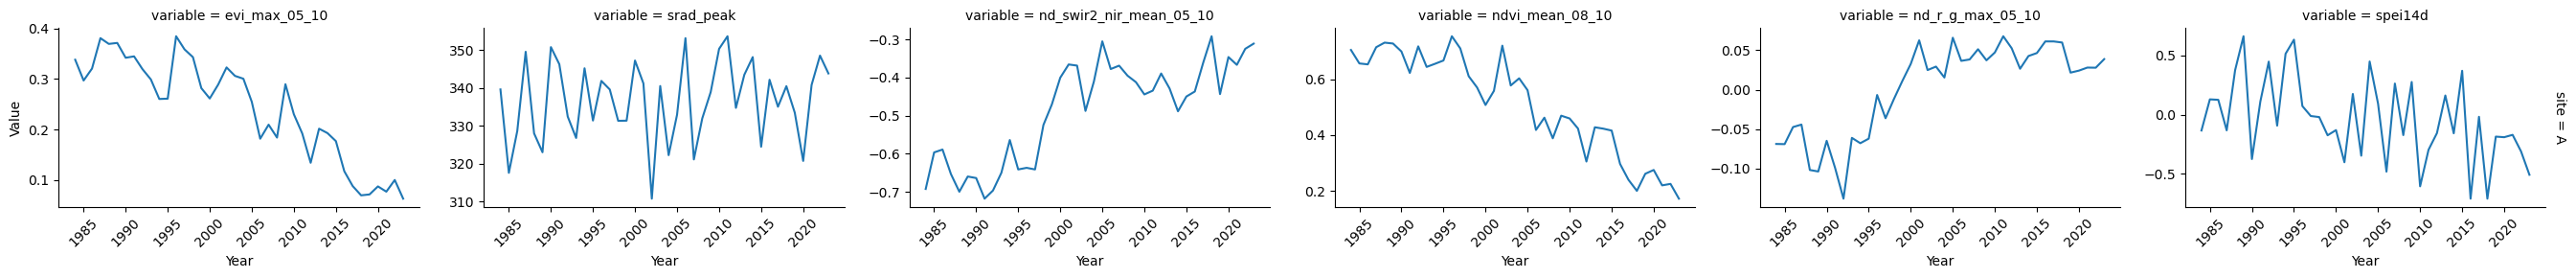

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    long_df,
    row='site',          # one row per site
    col='variable',      # one column per variable
    margin_titles=True,
    sharey=False,
    height=3,
    aspect=1.5
)

g.map_dataframe(
    sns.lineplot,
    x='year',
    y='value'
)

g.set_axis_labels("Year", "Value")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

##Save at high res
import os
output_dir = r'F:\Loose figures'
file_name = 'predictor trends at site A.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

In [102]:
#Fin